# Connect Ke GDrive

In [1]:
# ====================================
# 1️⃣ Mount Google Drive & Install Dependencies
# ====================================
from google.colab import drive
drive.mount('/content/drive')

!pip install transformers datasets seqeval

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=39a9d40af1e8daa7ea6cee7d0acf82990982bd38891bb4bca0ad32e0f2e49f76
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval


# Persiapan Dataset

In [2]:
# ====================================
# 2️⃣ Load Dataset dari Google Drive
# ====================================
import json

DATA_PATH = "/content/drive/MyDrive/Tugas Akhir/Dataset/(2.1-BERT) Labeling BIO/Movie_review_tokenized.json"
with open(DATA_PATH) as f:
    data = json.load(f)

print("Contoh data:", data[0])

Contoh data: {'tokens': ['also', ',', 'i', 'was', 'amazed', 'by', 'the', 'great', 'moral', 'message', 'that', 'this', 'movie', 'delivered', 'to', 'us', '.'], 'labels': ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-ASP', 'I-ASP', 'O', 'O', 'O', 'O', 'O', 'O', 'O']}


In [3]:
# ====================================
# 3️⃣ Buat Label Mapping
# ====================================
labels_list = [label for d in data for label in d["labels"]]
unique_labels = sorted(set(labels_list))

label2id = {label: i for i, label in enumerate(unique_labels)}
id2label = {i: label for label, i in label2id.items()}

print("Label2ID:", label2id)

Label2ID: {'B-ASP': 0, 'I-ASP': 1, 'O': 2}


In [4]:
# ====================================
# 4️⃣ Tokenisasi & Align Labels
# ====================================
from transformers import BertTokenizerFast

tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

def tokenize_and_align_labels(example):
    tokenized = tokenizer(example["tokens"], truncation=True, is_split_into_words=True)
    word_ids = tokenized.word_ids()

    labels = []
    prev_word_idx = None
    for word_idx in word_ids:
        if word_idx is None:
            labels.append(-100)  # token spesial (CLS/SEP)
        elif word_idx != prev_word_idx:
            labels.append(label2id[example["labels"][word_idx]])
        else:
            labels.append(label2id[example["labels"][word_idx]])
        prev_word_idx = word_idx

    tokenized["labels"] = labels
    return tokenized

tokenized_dataset = [tokenize_and_align_labels(d) for d in data]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [5]:
# ====================================
# 5️⃣ Convert ke HuggingFace Dataset
# ====================================
from datasets import Dataset

dataset = Dataset.from_list(tokenized_dataset)
dataset = dataset.train_test_split(test_size=0.2, seed=42)

# Parameter

In [7]:
# ====================================
# 6️⃣ Setup Multi-Parameter Experiment
# ====================================
from transformers import BertForTokenClassification, TrainingArguments, Trainer, DataCollatorForTokenClassification
import numpy as np
from seqeval.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import pandas as pd
import os

os.environ["WANDB_DISABLED"] = "true"

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=2)

    true_labels = [
        [id2label[l] for l in label if l != -100]
        for label in labels
    ]
    true_preds = [
        [id2label[p] for (p, l) in zip(pred_row, label_row) if l != -100]
        for pred_row, label_row in zip(preds, labels)
    ]

    return {
        "accuracy": accuracy_score(true_labels, true_preds),
        "f1": f1_score(true_labels, true_preds)
    }

param_sets = [
    {"name": "BERT-A", "lr": 2e-5, "batch_size": 4, "epochs": 3},
    {"name": "BERT-B", "lr": 2e-5, "batch_size": 8, "epochs": 3},
    {"name": "BERT-C", "lr": 5e-5, "batch_size": 4, "epochs": 3},
    {"name": "BERT-D", "lr": 5e-5, "batch_size": 8, "epochs": 3},
    {"name": "BERT-E", "lr": 3e-5, "batch_size": 4, "epochs": 3},
    {"name": "BERT-F", "lr": 3e-5, "batch_size": 8, "epochs": 3}
]

results = []
all_f1_curves = {}

# Fine-Tuning BERT

In [8]:
# ====================================
# 7️⃣ Loop Eksperimen
# ====================================
for params in param_sets:
    print(f"\n🚀 Training {params['name']} | LR={params['lr']} | BS={params['batch_size']} | EPOCH={params['epochs']}\n")

    model = BertForTokenClassification.from_pretrained(
        "bert-base-uncased",
        num_labels=len(unique_labels),
        id2label=id2label,
        label2id=label2id
    )

    args = TrainingArguments(
        output_dir=f"/content/{params['name']}",
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        learning_rate=params["lr"],
        per_device_train_batch_size=params["batch_size"],
        per_device_eval_batch_size=params["batch_size"],
        num_train_epochs=params["epochs"],
        weight_decay=0.01,
        report_to="none",
        logging_dir=f"/content/{params['name']}/logs"
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=dataset["train"],
        eval_dataset=dataset["test"],
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics
    )

    trainer.train()
    eval_metrics = trainer.evaluate()
    results.append({"name": params["name"], **params, **eval_metrics})

    history = trainer.state.log_history
    eval_f1 = [log["eval_f1"] for log in history if "eval_f1" in log]

    all_f1_curves[params["name"]] = eval_f1


🚀 Training BERT-A | LR=2e-05 | BS=4 | EPOCH=3



model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-3666752818.py:31: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.038700,0.022804,0.991347,0.824757
2,0.026100,0.021780,0.992295,0.837375
3,0.009100,0.031195,0.991999,0.831187



🚀 Training BERT-B | LR=2e-05 | BS=8 | EPOCH=3



...

Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-3666752818.py:31: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.036600,0.021798,0.991999,0.832281
2,0.022500,0.023264,0.992384,0.836630
3,0.006900,0.034154,0.992058,0.837741



🚀 Training BERT-F | LR=3e-05 | BS=8 | EPOCH=3



Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-3666752818.py:31: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.054800,0.023689,0.991199,0.819163
2,0.022800,0.022068,0.992295,0.845657
3,0.008600,0.030126,0.991525,0.830189


# Hasil Eksperimen

In [9]:
# ====================================
# 8️⃣ Simpan Hasil Semua Eksperimen ke CSV
# ====================================
df_results = pd.DataFrame(results)
csv_path = "/content/drive/MyDrive/Tugas Akhir/1.Model/2.BERT/bert_experiment_results.csv"
df_results.to_csv(csv_path, index=False)

print(f"\n✅ Semua eksperimen selesai. Hasil disimpan ke {csv_path}\n")


✅ Semua eksperimen selesai. Hasil disimpan ke /content/drive/MyDrive/Tugas Akhir/1.Model/2.BERT/bert_experiment_results.csv



# Grafik Eksperimen


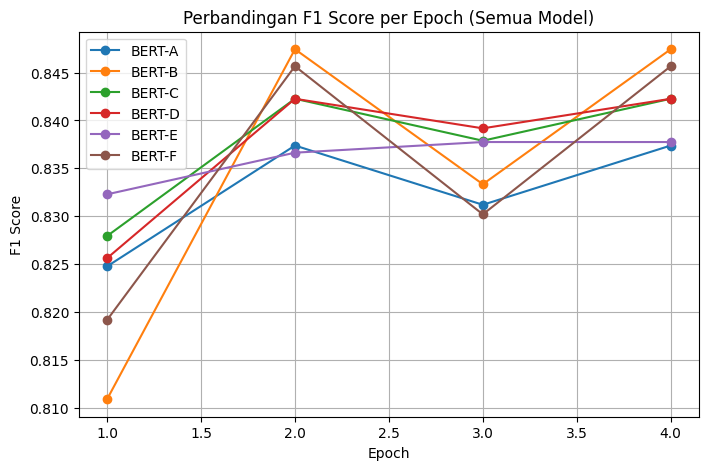

In [10]:
# ====================================
# 9️⃣ Grafik Multi-Line F1 per Epoch
# ====================================
plt.figure(figsize=(8,5))
for name, f1_values in all_f1_curves.items():
    plt.plot(range(1, len(f1_values)+1), f1_values, marker="o", label=name)

plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("Perbandingan F1 Score per Epoch (Semua Model)")
plt.legend()
plt.grid(True)
plt.show()

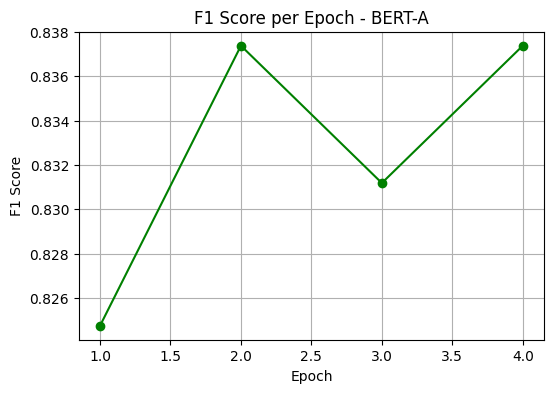

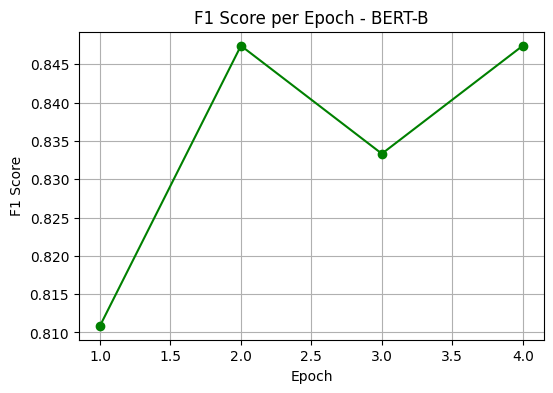

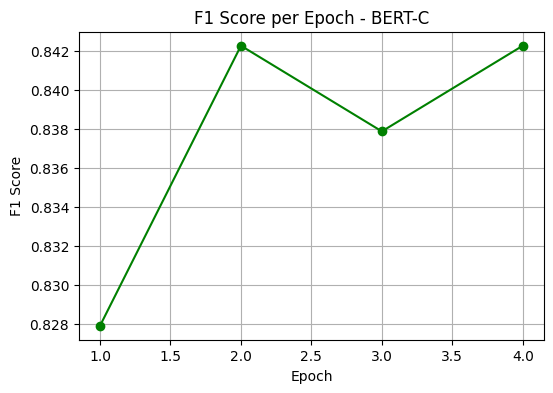

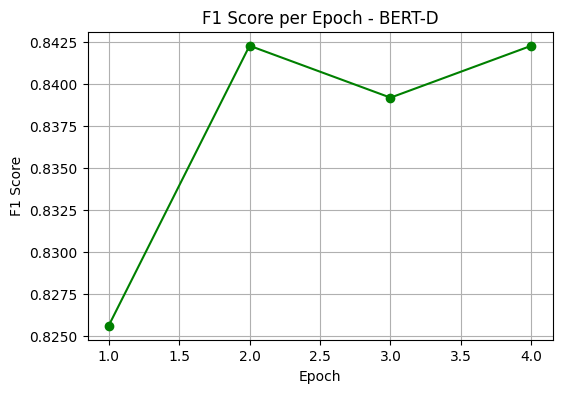

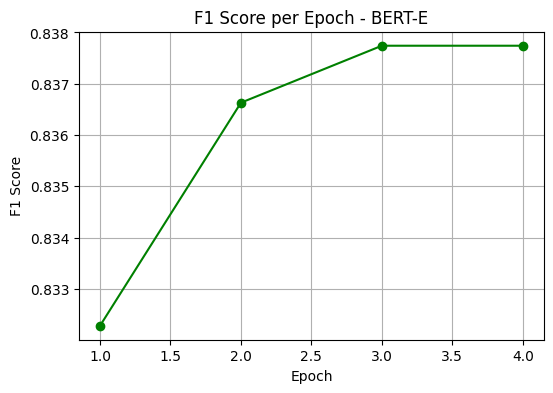

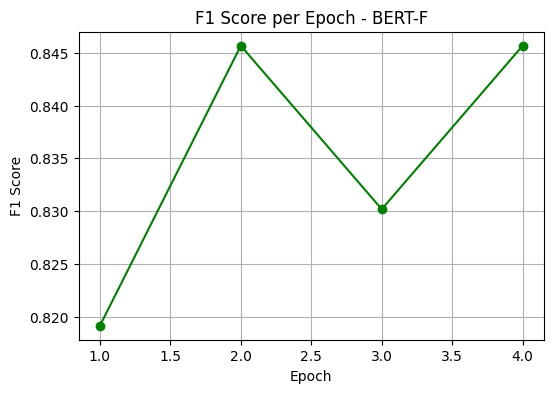

In [13]:
# ====================================
# 9️⃣a Grafik Terpisah F1 per Epoch (Satu Model Satu Grafik)
# ====================================
for name, f1_values in all_f1_curves.items():
    plt.figure(figsize=(6,4))
    plt.plot(range(1, len(f1_values)+1), f1_values, marker="o", color="green")
    plt.xlabel("Epoch")
    plt.ylabel("F1 Score")
    plt.title(f"F1 Score per Epoch - {name}")
    plt.grid(True)
    plt.show()


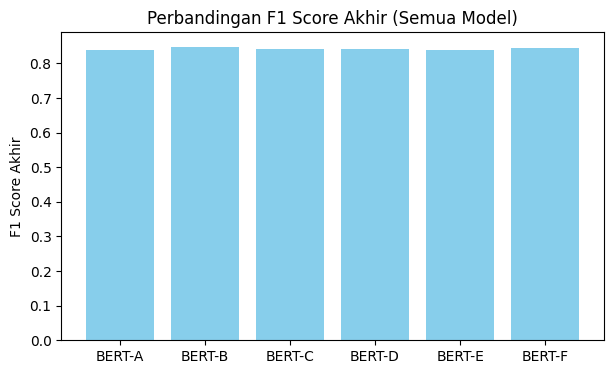

In [11]:
# ====================================
# 🔟 Grafik Bar: F1 Score Akhir
# ====================================
plt.figure(figsize=(7,4))
plt.bar(df_results["name"], df_results["eval_f1"], color="skyblue")
plt.ylabel("F1 Score Akhir")
plt.title("Perbandingan F1 Score Akhir (Semua Model)")
plt.show()

# Simpan Model Terbaik

In [12]:
# ====================================
# 1️⃣1️⃣ Latih ulang & simpan hanya model terbaik
# ====================================
best_row = df_results.loc[df_results["eval_f1"].idxmax()]
print("📌 Model terbaik:", best_row["name"], "| F1 =", best_row["eval_f1"])

best_params = {
    "lr": best_row["lr"],
    "batch_size": int(best_row["batch_size"]),
    "epochs": int(best_row["epochs"])
}

final_model = BertForTokenClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(unique_labels),
    id2label=id2label,
    label2id=label2id
)

final_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/Tugas Akhir/1.Model/2.BERT/Best_Model",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    learning_rate=best_params["lr"],
    per_device_train_batch_size=best_params["batch_size"],
    per_device_eval_batch_size=best_params["batch_size"],
    num_train_epochs=best_params["epochs"],
    weight_decay=0.01,
    report_to="none",
    logging_dir="/content/drive/MyDrive/Tugas Akhir/1.Model/2.BERT/Best_Model/logs"
)

final_trainer = Trainer(
    model=final_model,
    args=final_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

final_trainer.train()

final_trainer.save_model("/content/drive/MyDrive/Tugas Akhir/1.Model/2.BERT/Best_Model")
tokenizer.save_pretrained("/content/drive/MyDrive/Tugas Akhir/1.Model/2.BERT/Best_Model")

print("\n🎯 Model terbaik berhasil dilatih ulang dan disimpan ke Google Drive!\n")

📌 Model terbaik: BERT-B | F1 = 0.8474331164135936


Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-4007060194.py:37: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  final_trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.062100,0.027187,0.990251,0.806345
2,0.025900,0.021281,0.992592,0.847605
3,0.012800,0.026677,0.991999,0.837895



🎯 Model terbaik berhasil dilatih ulang dan disimpan ke Google Drive!

